In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf

ERROR 1: PROJ: proj_create_from_database: Open of /nesi/project/niwa00018/queenle/ml_env_v2/share/proj failed


In [2]:
# load observations
obs_dfs = {}
for var in ['temp','precip','streamflow']:
    seasonal_dfs = []
    for season in ['winter','spring','summer','autumn']:
        df = pd.read_csv('/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/obs/'+var+'/'+var+'_obs_'+season+'_gaussian.csv')
        seasonal_dfs.append(df)
        
    var_df = pd.concat(seasonal_dfs,axis=0)
    var_df['date'] = pd.to_datetime(var_df['date'])
    var_df = var_df.set_index('date').sort_index()
    if var == 'streamflow':
        var_df = var_df.drop('36001',axis=1)
        
    obs_dfs[var] = var_df

# load station-based model data
model_direc = '/nesi/project/niwa00015/queenle/data/hydro_fingerprinting/model/d4PDF/gaussian/'
model_dfs = {}
for var in ['TA','PRECIPI','ROF']:
    seasonal_dfs = []
    for season in ['winter','spring','summer','autumn']:
        df = pd.read_csv(model_direc+var+"/seasonal/station_resolution/"+var+'_d4PDF_HPB_ensMean_gaussian_'+season+'_1951-2021.csv')
        seasonal_dfs.append(df)
        
    var_df = pd.concat(seasonal_dfs,axis=0)
    var_df['time'] = pd.to_datetime(var_df['time'])
    var_df = var_df.set_index('time').sort_index()
    if var == 'ROF':
        var_df = var_df.drop('36001',axis=1)
    
    model_dfs[var] = var_df    

# load temp/precip station metadata
temp_meta_df = pd.read_csv('/home/queenle/hydro_attribution/station_data/temperature_17_series/17SS_meta.csv')
temp_meta_df.loc[6,'LONGT']=176.9 #slightly shift Napier so its nearest neighbor is not an ocean cell

precip_meta_df = pd.read_csv('/home/queenle/hydro_attribution/station_data/rainfall_21_series/rainfall_stns.csv')
precip_meta_df.loc[4,'LONGT']=176.9 #slightly shift Napier so its nearest neighbor is not an ocean cell
precip_meta_df.loc[5,'LONGT']=175.25 #slightly shift Napier so its nearest neighbor is not an ocean cell

# load streamflow metadata
streamflow_meta_df = pd.read_csv('/nesi/project/niwa00015/queenle/data/metadata/40_50yr_sites.csv')
streamflow_meta_df.set_index('Number',inplace=True)
streamflow_meta_df = streamflow_meta_df.loc[[int(s) for s in obs_dfs['streamflow'].columns]]
streamflow_meta_df.sort_values('gauge_lat', ascending = False, inplace=True)
streamflow_meta_df['number_label'] = np.arange(1,len(streamflow_meta_df)+1)
streamflow_meta_df['number_copy'] = streamflow_meta_df.index.values.tolist()


In [32]:
time_windows = {'TA':['1951','2020'],'temp':['1951','2020'],
                'PRECIPI':['1951','2020'],'precip':['1951','2020'],
                'ROF':['1969','2019'],'streamflow':['1969','2019']
               }

vrs_dict = {'temperature':['temp','TA'],
            'precipitation':['precip','PRECIPI'],
            'streamflow':['streamflow','ROF']}

season_dict = {6:'Winter',9:'Spring',12:'Summer',3:'Autumn'}

vlim_dict = {'TA':0.03,
             'temp':0.03,
             'PRECIPI':0.004,
             'precip':0.01,
             'ROF':0.01,
             'streamflow':0.03
            }

font = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'normal',
        'size': 22,
        }

In [4]:
def get_linregress_slope(arr):
    if (np.isnan(arr)).any():
        result = np.nan
    else:
        result = np.polyfit([i for i in range(len(arr))],arr,deg=1)[0]
        
    return(result)

In [5]:
def get_trend_info(var,df):
    
    lats = []
    lons = []
    slopes = []

    for site in df:

        ts = df[site].dropna()

        slopes.append(np.polyfit([i for i in range(len(ts))],ts,deg=1)[0])
        
        if var == 'precip' or var == 'PRECIPI':
            lats.append(precip_meta_df.loc[precip_meta_df['station'] == site]['LAT'].values[0])
            lons.append(precip_meta_df.loc[precip_meta_df['station'] == site]['LONGT'].values[0])
            
        elif var == 'temp' or var == 'TA':
            lats.append(temp_meta_df.loc[temp_meta_df['station'] == site]['LAT'].values[0])
            lons.append(temp_meta_df.loc[temp_meta_df['station'] == site]['LONGT'].values[0])
            
        elif var == 'streamflow' or var == 'ROF':
            lats.append((streamflow_meta_df.loc[int(site)]['centroid_lat']))
            lons.append(streamflow_meta_df.loc[int(site)]['centroid_lon'])
            
    return(lats,lons,slopes)

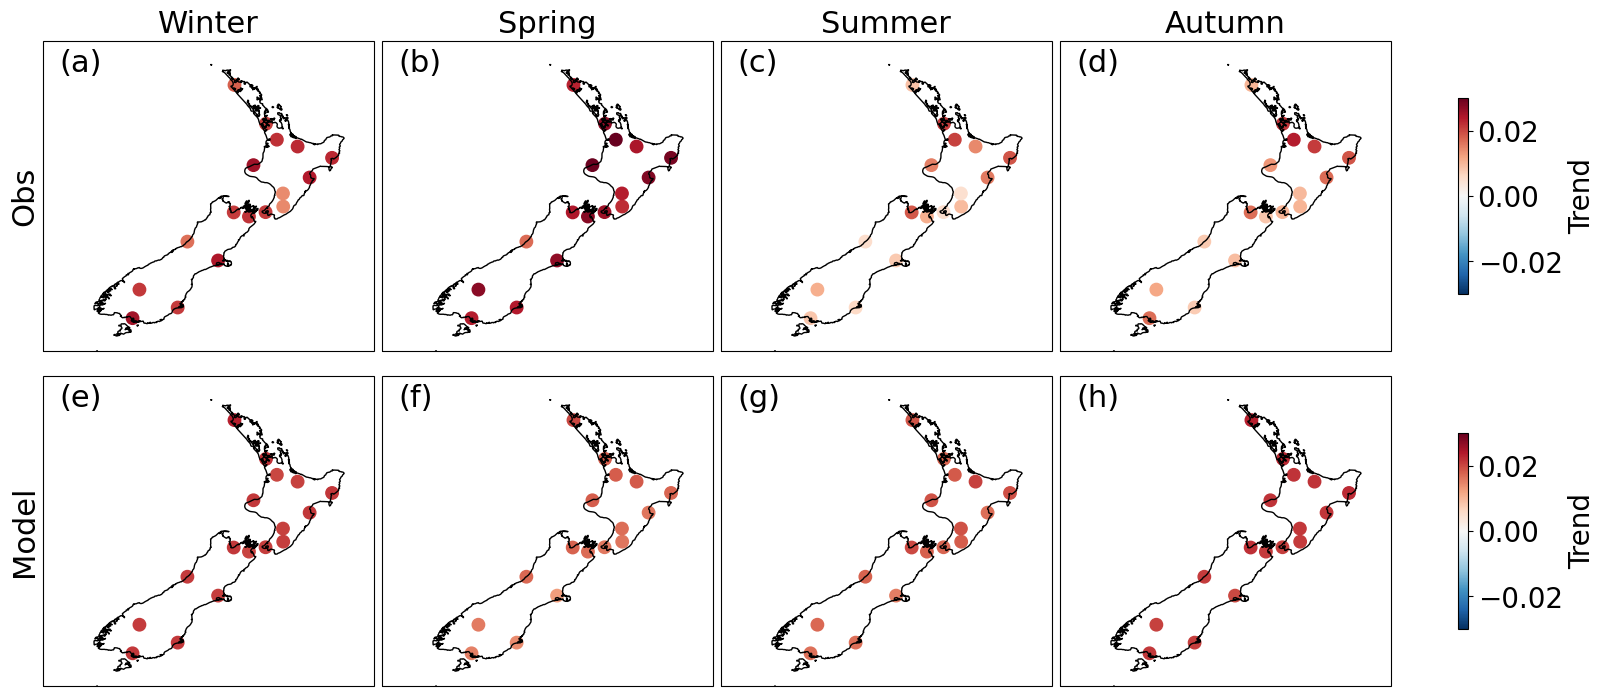

In [36]:
fig,axs = plt.subplots(2,4,figsize=(16,7),subplot_kw=dict(projection=ccrs.PlateCarree()),layout="constrained")

v = 'temperature'
vrs = vrs_dict[v]

labels = [['(a)','(b)','(c)','(d)'],
          ['(e)','(f)','(g)','(h)']]
for i,df_dict in enumerate([obs_dfs,model_dfs]):
    
    var  = vrs[i]
    
    for j,season in enumerate([6,9,12,3]):
        
        ax = axs[i][j]
        
        df = df_dict[var]
        df = df.loc[(df.index.month == season)][time_windows[var][0]:time_windows[var][1]]
        
        lats, lons, slopes = get_trend_info(var,df)
        
        im = ax.scatter(lons,lats,c=slopes,cmap='RdBu_r',marker='o',s=80,vmin=-vlim_dict[var],vmax=vlim_dict[var])

        ax.coastlines()
        ax.add_feature(cf.BORDERS)
        ax.set_extent([164,180, -48,-33])#, crs=noproj)
        
        if i == 0:
            ax.set_title(season_dict[season],fontdict=font)
            
        if j == 0:
            ax.text(-0.1,0.5,['Obs','Model'][i],transform=ax.transAxes,rotation=90,fontdict=font,va='center')

        if j == 3:
            cbar = fig.colorbar(im, ax=axs[i,:],shrink=0.6)
            cbar.set_label(label='Trend',size=20)
            cbar.ax.tick_params(labelsize=20)
            
        ax.text(0.05,0.9,labels[i][j],transform=ax.transAxes,fontdict=font)
        
plt.savefig('/home/queenle/hydro_attribution/dissertation/figures/obs_v_model_'+v+'_trend_maps.png',dpi=300)

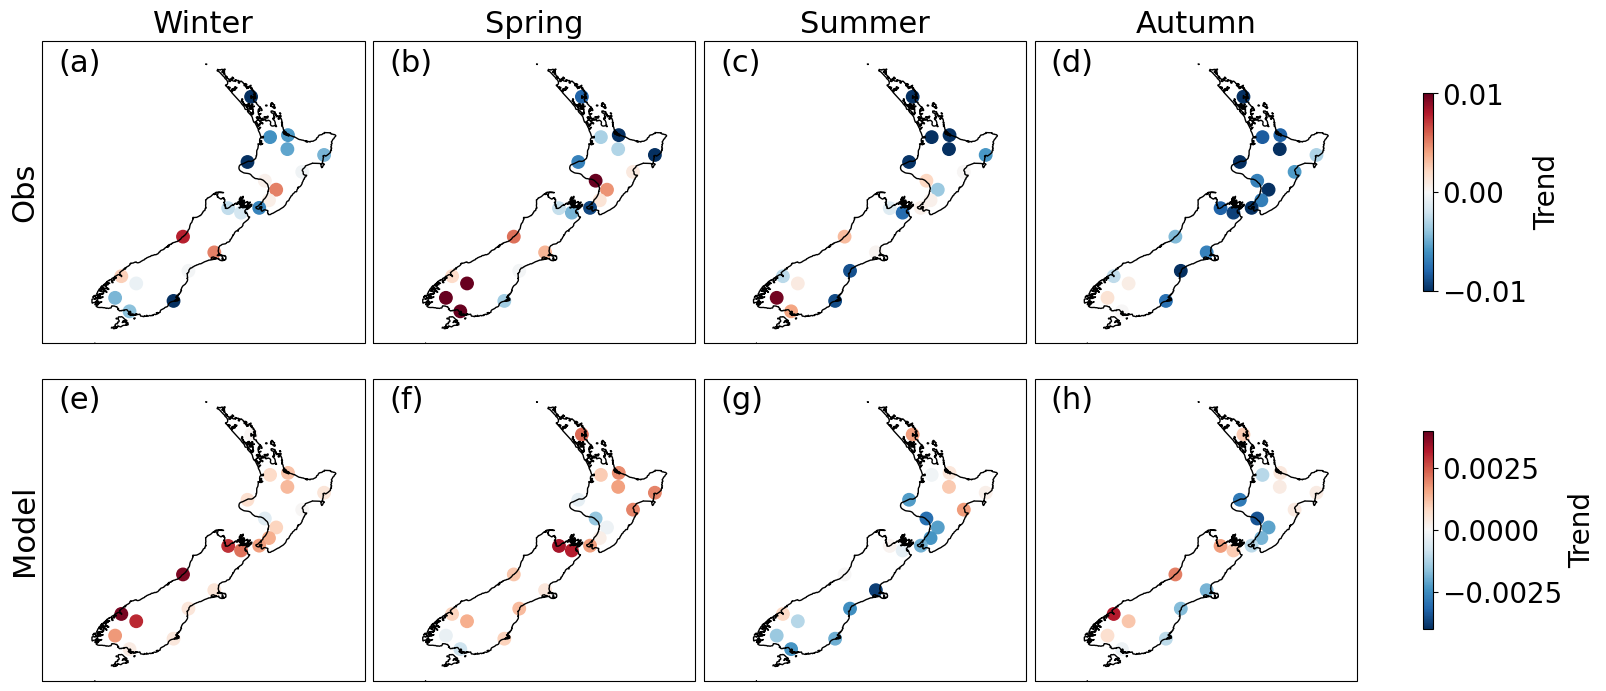

In [35]:
fig,axs = plt.subplots(2,4,figsize=(16,7),subplot_kw=dict(projection=ccrs.PlateCarree()),layout="constrained")

v = 'precipitation'
vrs = vrs_dict[v]
labels = [['(a)','(b)','(c)','(d)'],
          ['(e)','(f)','(g)','(h)']]

for i,df_dict in enumerate([obs_dfs,model_dfs]):
    
    var  = vrs[i]
    
    for j,season in enumerate([6,9,12,3]):
        
        ax = axs[i][j]
        
        df = df_dict[var]
        df = df.loc[(df.index.month == season)][time_windows[var][0]:time_windows[var][1]]
        
        lats, lons, slopes = get_trend_info(var,df)
        
        im = ax.scatter(lons,lats,c=slopes,cmap='RdBu_r',marker='o',s=80,vmin=-vlim_dict[var],vmax=vlim_dict[var])

        ax.coastlines()
        ax.add_feature(cf.BORDERS)
        ax.set_extent([164,180, -48,-33])#, crs=noproj)
        
        if i == 0:
            ax.set_title(season_dict[season],fontdict=font)
            
        if j == 0:
            ax.text(-0.1,0.5,['Obs','Model'][i],transform=ax.transAxes,rotation=90,fontdict=font,va='center')

        if j == 3:
            cbar = fig.colorbar(im, ax=axs[i,:],shrink=0.6)
            cbar.set_label(label='Trend',size=20)
            cbar.ax.tick_params(labelsize=20)
            
        ax.text(0.05,0.9,labels[i][j],transform=ax.transAxes,fontdict=font)
            
plt.savefig('/home/queenle/hydro_attribution/dissertation/figures/obs_v_model_'+v+'_trend_maps.png',dpi=300)

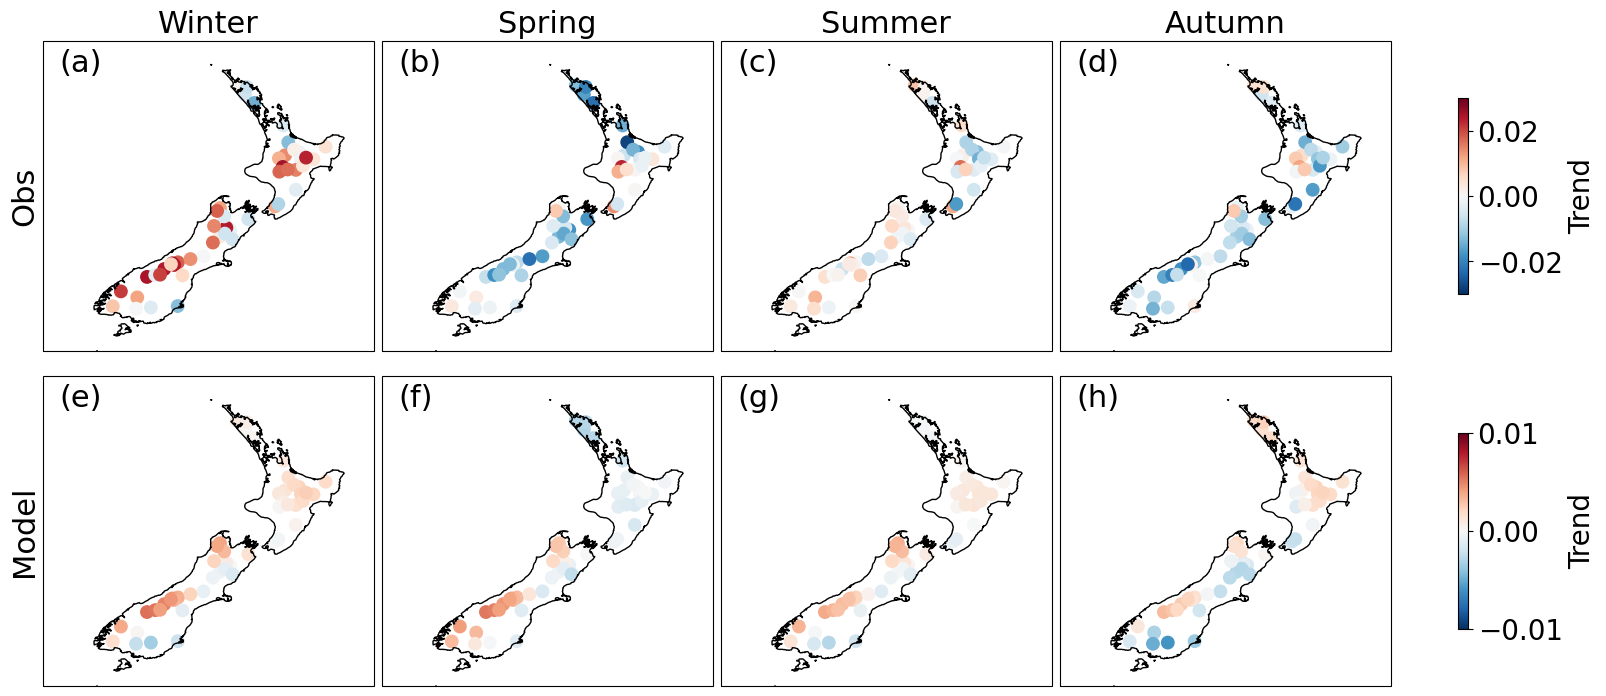

In [34]:
fig,axs = plt.subplots(2,4,figsize=(16,7),subplot_kw=dict(projection=ccrs.PlateCarree()),layout="constrained")

v = 'streamflow'
vrs = vrs_dict[v]
labels = [['(a)','(b)','(c)','(d)'],
          ['(e)','(f)','(g)','(h)']]

for i,df_dict in enumerate([obs_dfs,model_dfs]):
    
    var  = vrs[i]
    
    for j,season in enumerate([6,9,12,3]):
        
        ax = axs[i][j]
        
        df = df_dict[var]
        df = df.loc[(df.index.month == season)][time_windows[var][0]:time_windows[var][1]]
        
        lats, lons, slopes = get_trend_info(var,df)
        
        im = ax.scatter(lons,lats,c=slopes,cmap='RdBu_r',marker='o',s=80,vmin=-vlim_dict[var],vmax=vlim_dict[var])

        ax.coastlines()
        ax.add_feature(cf.BORDERS)
        ax.set_extent([164,180, -48,-33])#, crs=noproj)
        
        if i == 0:
            ax.set_title(season_dict[season],fontdict=font)
            
        if j == 0:
            ax.text(-0.1,0.5,['Obs','Model'][i],transform=ax.transAxes,rotation=90,fontdict=font,va='center')

        if j == 3:
            cbar = fig.colorbar(im, ax=axs[i,:],shrink=0.6)
            cbar.set_label(label='Trend',size=20)
            cbar.ax.tick_params(labelsize=20)
            
        ax.text(0.05,0.9,labels[i][j],transform=ax.transAxes,fontdict=font)
            
plt.savefig('/home/queenle/hydro_attribution/dissertation/figures/obs_v_model_'+v+'_trend_maps.png',dpi=300)